# Steam Review Surge Analysis — Stage 1: Data Pipeline
### Thesis Analysis — Building the Clean Weekly Panel

---

## What this notebook does

This notebook takes two raw data sources and produces a single clean panel dataset ready for surge detection (Stage 2) and panel regression (Stage 3).

**Inputs:**
- `games.json` — Steam game metadata (~65,000+ games)
- `aggregated_reviews_weekly.csv` — Weekly review aggregations (2020–2024)

**Output:** `panel_stage1_clean.csv` — one row per (game × time period), commercial games only, with metadata merged in and macroeconomic period flags attached.

---

## Analytical decisions documented here

| Decision | Value | Rationale |
|---|---|---|
| Date window | 2020–2024 | Covers COVID, inflation, and baseline periods |
| Commercial filter | `estimated_owners != '0 - 0'` | Removes playtests/demos/betas |
| English filter | `supported_languages` contains 'English' | Standardises review language |
| Min lifetime reviews | >= 50 | Eliminates games too sparse for a reliable baseline |
| Min active periods | >= 8 | Needed for rolling window to have sufficient history |


pos_share is the percentage of positive reviews, and it is exactly what Steam shows publicly (like “Mostly Positive — 78%”). This makes it easy to interpret and a strong choice for the main outcome (dependent variable).

One important limitation to mention:
- pos_share is based on reviews written during that week, not when the game was bought.
- Some players may have bought the game years ago but only posted their review during the surge week.

→ This means the sentiment in a surge week reflects who chose to write reviews at that time, which introduces a selection effect. This should be clearly acknowledged in the methods section.

# 1. Import Libraries


In [43]:
from google.colab import drive
import os, json, warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

print('Libraries loaded.')

Libraries loaded.


---
# 2. Load Raw Data

## 2.1 Mount Drive and set paths


In [44]:
drive.mount('/content/drive')

BASE_PATH    = 'drive/My Drive/Notebooks/PersonalResearch'
META_PATH    = f'{BASE_PATH}/games.json'
REVIEWS_PATH = f'{BASE_PATH}/aggregated_reviews_weekly.csv'
OUTPUT_PATH  = f'{BASE_PATH}/panel_stage1_clean.csv'

#OUTPUT_PATH  = f'{BASE_PATH}/panel_stage1_lr200.csv'

print(f'Meta    : {META_PATH}')
print(f'Reviews : {REVIEWS_PATH}')
print(f'Output  : {OUTPUT_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Meta    : drive/My Drive/Notebooks/PersonalResearch/games.json
Reviews : drive/My Drive/Notebooks/PersonalResearch/aggregated_reviews_weekly.csv
Output  : drive/My Drive/Notebooks/PersonalResearch/panel_stage1_lr200.csv


## 2.2 Load Game Metadata

| Variable | Definition |
|---|---|
| `appID` | Unique Steam game identifier |
| `name` | Game title |
| `release_date` | Official release date |
| `price` | Price in USD |
| `estimated_owners` | Ownership range bracket |
| `supported_languages` | Languages supported |
| `positive` / `negative` | Lifetime review counts |


In [45]:
with open(META_PATH, 'r', encoding='utf-8') as f:
    meta = json.load(f)

raw_df = pd.DataFrame(meta)
meta_df = raw_df.T.copy()
meta_df.index.name = 'appID'
meta_df.reset_index(inplace=True)

print(f'Raw metadata rows : {len(meta_df):,}')
print(f'Columns           : {list(meta_df.columns)}')
meta_df.head(3)

Raw metadata rows : 65,686
Columns           : ['appID', 'name', 'release_date', 'required_age', 'price', 'detailed_description', 'about_the_game', 'short_description', 'supported_languages', 'full_audio_languages', 'categories', 'genres', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags']


,appID,name,release_date,required_age,price,detailed_description,about_the_game,short_description,supported_languages,full_audio_languages,...,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags
0,1724540,Welcome to Goodland,"Apr 28, 2023",0,16.9900,Join our Discord! About the Game You could nev...,You could never have known you would end up in...,It is a strategy/adventure game set in a small...,[English],[],...,25,8,0 - 20000,0,0,0,0,0,0,"{'Choose Your Own Adventure': 332, 'Time Manag..."
1,2201840,그녀가 다시 노래할 때까지.,"Nov 14, 2022",0,4.9900,ABOUT THE GAME 'Until She sings again' is a ro...,ABOUT THE GAME 'Until She sings again' is a ro...,My friend has become a girl after I came back ...,[Korean],[Korean],...,8,2,0 - 20000,0,0,0,0,0,0,"{'Simulation': 67, 'Visual Novel': 40, '2D': 3..."
2,1364180,Counter Operation Online,"Nov 1, 2020",0,14.9900,Counter Operation Online (COO) shooter require...,Counter Operation Online (COO) shooter require...,Counter Operation Online ( COO ) revived by th...,[English],[English],...,1,1,0 - 20000,0,0,0,0,0,0,"{'Shooter': 50, 'FPS': 45, 'First-Person': 42,..."


## 2.3 Load Review Data


In [46]:
review_df = pd.read_csv(REVIEWS_PATH, parse_dates=['year_week'])
if 'Unnamed: 0' in review_df.columns:
    review_df = review_df.drop(columns=['Unnamed: 0'])

# Confirm the columns you actually have
print(f'Review rows   : {len(review_df):,}')
print(f'Unique games  : {review_df["appID"].nunique():,}')
print(f'Columns       : {list(review_df.columns)}')
review_df.head(3)

Review rows   : 1,357,690
Unique games  : 23,098
Columns       : ['appID', 'iso_year', 'iso_week', 'year_week', 'n_reviews', 'pos_share', 'avg_helpful']


,appID,iso_year,iso_week,year_week,n_reviews,pos_share,avg_helpful
0,1000000,2021,19,2021-05-10,6,1.0000,6.1667
1,1000000,2021,20,2021-05-17,9,1.0000,2.7778
2,1000000,2021,21,2021-05-24,3,1.0000,1.6667


---
# 3. Data Cleaning


## 3.1 Data Type Conversion

All IDs as strings for consistent merging. Numeric fields coerced so malformed entries become `NaN`.


In [47]:
meta_df['appID']   = meta_df['appID'].astype(str)
review_df['appID'] = review_df['appID'].astype(str)

for col in ['price', 'discount', 'positive', 'negative']:
    if col in meta_df.columns:
        meta_df[col] = pd.to_numeric(meta_df[col], errors='coerce')

meta_df['release_date']  = pd.to_datetime(meta_df['release_date'],  errors='coerce')
review_df['year_week'] = pd.to_datetime(review_df['year_week'], errors='coerce')

print('Type conversion complete.')
print(meta_df[['appID','price','release_date']].dtypes)

Type conversion complete.
appID                   object
price                  float64
release_date    datetime64[ns]
dtype: object


## 3.2 Date Window: 2020–2024

This window covers three macroeconomic periods central to the thesis:

- **COVID-19 lockdowns** (Mar 2020 – Jun 2021): gaming demand spike, market saturation
- **Post-COVID normalisation** (Jul 2021 – Feb 2022): demand correction
- **Inflation / cost-of-living** (Mar 2022 – Dec 2023): constrained consumer spending

Games released before 2020 are excluded; review data is filtered to the same range.


In [48]:
before = len(meta_df)
meta_df = meta_df[
    (meta_df['release_date'] >= '2020-01-01') &
    (meta_df['release_date'] <= '2024-12-31')
].copy()
print(f'Meta after date filter: {len(meta_df):,} (removed {before - len(meta_df):,})')

before = len(review_df)
review_df = review_df[
    (review_df['year_week'] >= '2020-01-01') &
    (review_df['year_week'] <= '2024-12-31')
].copy()
print(f'Reviews after date filter: {len(review_df):,} (removed {before - len(review_df):,})')

Meta after date filter: 65,686 (removed 0)
Reviews after date filter: 1,328,147 (removed 29,543)


## 3.3 Commercial vs Playtest Split

Games with `estimated_owners == '0 - 0'` are playtests, demos, or unreleased betas —
they have fundamentally different review dynamics (closed access, controlled audiences)
that would contaminate the commercial analysis.

All subsequent analysis uses `meta_commercial` and `review_commercial` only.


In [49]:
commercial_mask = meta_df['estimated_owners'] != '0 - 0'

meta_commercial = meta_df[commercial_mask].copy()
meta_playtest   = meta_df[~commercial_mask].copy()

commercial_ids = set(meta_commercial['appID'].astype(str))

review_df['appID'] = review_df['appID'].astype(str)
review_commercial = review_df[review_df['appID'].isin(commercial_ids)].copy()
review_playtest   = review_df[~review_df['appID'].isin(commercial_ids)].copy()

print(f'Commercial games   : {len(meta_commercial):,}')
print(f'Playtest games     : {len(meta_playtest):,}')
print(f'Commercial reviews : {len(review_commercial):,}')
print(f'Playtest reviews   : {len(review_playtest):,}')

Commercial games   : 52,165
Playtest games     : 13,521
Commercial reviews : 1,145,396
Playtest reviews   : 182,751


## 3.4 English Language Filter

Restricting to English-supported games ensures `pos_share` reflects a consistent
linguistic baseline and aligns with the majority of Steam's review ecosystem.


In [50]:
if 'supported_languages' in meta_commercial.columns:
    meta_commercial = meta_commercial.copy()
    meta_commercial['has_english'] = (
        meta_commercial['supported_languages']
        .astype(str)
        .str.contains('English', case=False, na=False)
    )
    before = len(meta_commercial)
    meta_commercial = meta_commercial[meta_commercial['has_english']].copy()
    print(f'After English filter: {len(meta_commercial):,} games (removed {before - len(meta_commercial):,})')
else:
    print('supported_languages not found — skipping filter')

After English filter: 49,624 games (removed 2,541)


## 3.5 Minimum Lifetime Reviews Filter

Games with very few total reviews have highly volatile period-level counts.
A game going from 0 to 3 reviews trips any surge threshold, but this is
noise — not a meaningful signal.

> **Robustness check:** Re-run with 100 and 200 as alternative thresholds in Stage 3.


In [51]:
MIN_LIFETIME_REVIEWS  = 100
MIN_AVG_WEEKLY_REVIEWS = 3   # must average at least 3 reviews per week becuase when investigating the flatline changes => all getting exactly 1 review per week. Purpose: eliminating zero-variance baselines

# Existing lifetime filter
lifetime = review_commercial.groupby('appID')['n_reviews'].sum()
eligible_lifetime = lifetime[lifetime >= MIN_LIFETIME_REVIEWS].index

# New average weekly filter
avg_weekly = review_commercial.groupby('appID')['n_reviews'].mean()
eligible_weekly = avg_weekly[avg_weekly >= MIN_AVG_WEEKLY_REVIEWS].index

# Both must be satisfied
eligible_ids = eligible_lifetime.intersection(eligible_weekly)

before = review_commercial['appID'].nunique()
review_commercial = review_commercial[
    review_commercial['appID'].isin(eligible_ids)
].copy()
print(f'After combined filter: {review_commercial["appID"].nunique():,} games '
      f'(removed {before - review_commercial["appID"].nunique():,})')

After combined filter: 5,786 games (removed 12,992)


## 3.6 Minimum Active Periods Filter

The rolling-window baseline (Stage 2) requires at least 6 periods of history
before producing a reliable baseline. Games below this floor can never generate
a valid surge flag, include them only wastes memory and skews the surge rate.

Stage 2 uses an 8-week window, so the first valid surge can only be detected
from period 9 onwards. This means **launch-week surges are intentionally excluded**.


In [52]:
MIN_ACTIVE_PERIODS = 8

period_counts = review_commercial.groupby('appID')['year_week'].nunique()
eligible_ids  = period_counts[period_counts >= MIN_ACTIVE_PERIODS].index

before = review_commercial['appID'].nunique()
review_commercial = review_commercial[review_commercial['appID'].isin(eligible_ids)].copy()
print(f'After min-periods filter: {review_commercial["appID"].nunique():,} games '
      f'(removed {before - review_commercial["appID"].nunique():,})')

# Align metadata to the same set
valid_appids    = set(review_commercial['appID'].unique())
meta_commercial = meta_commercial[meta_commercial['appID'].isin(valid_appids)].copy()
print(f'Aligned metadata : {len(meta_commercial):,} games')

After min-periods filter: 5,691 games (removed 95)
Aligned metadata : 5,430 games


## 3.7 Duplicate Handling

Check for (appID, year_month) duplicates — can arise from data collection overlaps.
Where found, sum review counts and average share metrics.


In [53]:
dupes = review_commercial.duplicated(subset=['appID', 'year_week'], keep=False).sum()
print(f'Duplicate (appID, year_month) rows: {dupes:,}')

if dupes > 0:
    review_commercial = (
        review_commercial
        .groupby(['appID', 'year_week'])
        .agg({'n_reviews': 'sum', 'pos_share': 'mean', 'avg_helpful': 'mean'})
        .reset_index()
    )
    print(f'After dedup: {len(review_commercial):,} rows')
else:
    print('No duplicates found.')

Duplicate (appID, year_month) rows: 0
No duplicates found.


---
# 4. Temporal Granularity


In [54]:
panel = review_commercial.copy()
panel['year_week'] = pd.to_datetime(panel['year_week'])

GRANULARITY = 'weekly'
TIME_COL    = 'year_week'

panel = panel.sort_values(['appID', 'year_week']).reset_index(drop=True)

print(f'Weekly panel ready: {len(panel):,} rows, {panel["appID"].nunique():,} games')
print(f'Date range: {panel["year_week"].min().date()}  to  {panel["year_week"].max().date()}')
print(f'Columns: {list(panel.columns)}')

Weekly panel ready: 653,354 rows, 5,691 games
Date range: 2020-01-06  to  2024-12-02
Columns: ['appID', 'iso_year', 'iso_week', 'year_week', 'n_reviews', 'pos_share', 'avg_helpful']


---
# 5. Build Metadata Features

These features are needed for heterogeneity analysis in Stage 3.
Compute them from metadata before the merge so every observation inherits the right context.


## 5.1 Price Tier

Free vs. paid games have different review dynamics. Free games attract less invested
players — surges are noisier signals. Paid games have committed players, so their
reviews are more considered. Price tier moderates the surge–satisfaction relationship (H2).


In [55]:
meta_commercial = meta_commercial.copy()
meta_commercial['price'] = pd.to_numeric(meta_commercial['price'], errors='coerce').fillna(0)

def assign_price_tier(price):
    if price == 0:       return 'free'
    elif price < 10:     return 'low'      # $0.01–$9.99
    elif price < 30:     return 'mid'      # $10–$29.99
    else:                return 'premium'  # $30+

meta_commercial['price_tier'] = meta_commercial['price'].apply(assign_price_tier)

print('Price tier distribution:')
print(meta_commercial['price_tier'].value_counts())

Price tier distribution:
price_tier
mid        2684
low        1819
premium     524
free        403
Name: count, dtype: int64


## 5.2 Lifetime Satisfaction Score

A lifetime satisfaction proxy computed from metadata review counts.
Serves as a baseline quality control in the regression — isolating surge effects
from the simple fact that better games get better reviews at all times.


In [56]:
for col in ['positive', 'negative']:
    meta_commercial[col] = pd.to_numeric(meta_commercial[col], errors='coerce').fillna(0)

meta_commercial['total_lifetime_reviews'] = (
    meta_commercial['positive'] + meta_commercial['negative']
)
meta_commercial['lifetime_pos_share'] = np.where(
    meta_commercial['total_lifetime_reviews'] > 0,
    meta_commercial['positive'] / meta_commercial['total_lifetime_reviews'],
    np.nan
)

print('Lifetime satisfaction summary:')
print(meta_commercial['lifetime_pos_share'].describe())

Lifetime satisfaction summary:
count   5105.0000
mean       0.8296
std        0.1269
min        0.1030
25%        0.7640
50%        0.8590
75%        0.9272
max        1.0000
Name: lifetime_pos_share, dtype: float64


---
# 6. Merge Metadata onto Panel

Left join — all review observations are kept; metadata is attached.
Any panel row with no matching metadata (should be zero after the Section 3.6 alignment)
will show NaN metadata columns.


In [57]:
meta_cols = [
    'appID', 'name', 'release_date', 'price', 'price_tier',
    'lifetime_pos_share', 'total_lifetime_reviews'
]
for col in ['genres', 'categories']:
    if col in meta_commercial.columns:
        meta_cols.append(col)

meta_slim = meta_commercial[[c for c in meta_cols if c in meta_commercial.columns]].copy()

panel_merged = panel.merge(meta_slim, on='appID', how='inner')
dropped = panel['appID'].nunique() - panel_merged['appID'].nunique()
print(f'Games before merge : {panel["appID"].nunique():,}')
print(f'Games after merge  : {panel_merged["appID"].nunique():,}')
print(f'Games dropped      : {dropped:,}')

Games before merge : 5,691
Games after merge  : 5,430
Games dropped      : 261


In [58]:

# Game age at each observation: critical for the launch vs. mature split
panel_merged['release_date'] = pd.to_datetime(panel_merged['release_date'])
panel_merged['obs_date']     = pd.to_datetime(panel_merged['year_week'])
panel_merged['game_age_months'] = (
    (panel_merged['obs_date'].dt.year  - panel_merged['release_date'].dt.year)  * 12 +
    (panel_merged['obs_date'].dt.month - panel_merged['release_date'].dt.month)
)

panel_merged['is_mature'] = panel_merged['game_age_months'] >= 6

# Mature = 6+ months post-launch
# Newly released surges = likely launch hype / expectation inflation
# Mature surges = likely genuine quality signals (patches, viral moments)
panel_merged['is_mature'] = panel_merged['game_age_months'] >= 6

print(f'Panel rows after merge : {len(panel_merged):,}')
print(f'Games in panel         : {panel_merged["appID"].nunique():,}')

Panel rows after merge : 627,631
Games in panel         : 5,430


## 6.2 Macroeconomic Period Flags


- During COVID, market saturation meant individual quality signals were less informative (everyone was gaming regardless of quality), so surge effects on satisfaction should be weaker.
- During the inflation period, players were more selective, so surges may have attracted a more engaged composition — potentially strengthening the satisfaction signal.

| Period | Dates | Reference |
|---|---|---|
| `covid` | Mar 2020 – Jun 2021 | Lockdowns, gaming demand spike |
| `post_covid` | Jul 2021 – Feb 2022 | Demand correction |
| `inflation` | Mar 2022 – Dec 2023 | Cost-of-living pressure |
| `baseline` | All other dates | Reference category in regression |

Because the sample is restricted to games released during 2020–2024, the COVID period contains a disproportionate share of newly released titles relative to the actual distribution of Steam activity during lockdowns. Established pre-2020 titles, which dominated gaming during the pandemic, are excluded. This may cause the COVID interaction coefficient to partially capture new-release dynamics rather than pure macroeconomic context effects.

In [59]:
obs = pd.to_datetime(panel_merged['year_week'])

covid_start     = pd.Timestamp('2020-03-01')
covid_end       = pd.Timestamp('2021-06-30')
post_covid_end  = pd.Timestamp('2022-02-28')
inflation_end   = pd.Timestamp('2023-12-31')

panel_merged['period'] = 'baseline'
panel_merged.loc[(obs >= covid_start)   & (obs <= covid_end),     'period'] = 'covid'
panel_merged.loc[(obs > covid_end)      & (obs <= post_covid_end),'period'] = 'post_covid'
panel_merged.loc[(obs > post_covid_end) & (obs <= inflation_end), 'period'] = 'inflation'

panel_merged['covid_period']     = (panel_merged['period'] == 'covid').astype(int)
panel_merged['inflation_period'] = (panel_merged['period'] == 'inflation').astype(int)
panel_merged['post_covid_period']= (panel_merged['period'] == 'post_covid').astype(int)

print('Period distribution:')
print(panel_merged.groupby('period').agg(
    rows=('appID','count'),
    games=('appID', 'nunique')
).sort_index())

Period distribution:
              rows  games
period                   
baseline    203928   5429
covid        72071   1763
inflation   283559   4524
post_covid   68073   2446


---
# 7. Final Quality Checks

In [60]:
print(f'Total rows              : {len(panel_merged):,}')
print(f'Unique games            : {panel_merged["appID"].nunique():,}')
print(f'Granularity             : {GRANULARITY}')
print(f'Date range              : {panel_merged["year_week"].min().date()}  '
      f'to  {panel_merged["year_week"].max().date()}')
print()

# Check 1: Missing DV
missing_dv = panel_merged['pos_share'].isna().mean()
dv_flag = 'OK' if missing_dv < 0.05 else 'WARNING >5%'
print(f'Missing pos_share (DV)  : {missing_dv:.2%}  [{dv_flag}]')

# Check 2: n_reviews sanity
neg_reviews = (panel_merged['n_reviews'] <= 0).sum()
print(f'Rows with n_reviews <= 0: {neg_reviews:,}')

# Check 3: pos_share range
out_of_range = ((panel_merged['pos_share'] < 0) | (panel_merged['pos_share'] > 1)).sum()
print(f'pos_share outside [0,1] : {out_of_range:,}')

# Check 4: Period coverage
print()
print('Period coverage:')
for p in ['baseline', 'covid', 'post_covid', 'inflation']:
    n = (panel_merged['period'] == p).sum()
    g = panel_merged[panel_merged['period'] == p]['appID'].nunique()
    flag = '' if n > 0 else '  *** MISSING ***'
    print(f'  {p:<15}: {n:>8,} rows  {g:>6,} games{flag}')

# Check 5: Game maturity
print()
print('Game maturity split:')
print(f'  Newly released (< 6 mo) : {(~panel_merged["is_mature"]).sum():,} obs')
print(f'  Mature games   (>= 6 mo) : {panel_merged["is_mature"].sum():,} obs')

Total rows              : 627,631
Unique games            : 5,430
Granularity             : weekly
Date range              : 2020-01-06  to  2024-12-02

Missing pos_share (DV)  : 0.00%  [OK]
Rows with n_reviews <= 0: 0
pos_share outside [0,1] : 0

Period coverage:
  baseline       :  203,928 rows   5,429 games
  covid          :   72,071 rows   1,763 games
  post_covid     :   68,073 rows   2,446 games
  inflation      :  283,559 rows   4,524 games

Game maturity split:
  Newly released (< 6 mo) : 183,645 obs
  Mature games   (>= 6 mo) : 443,986 obs


## 7.2 Diagnostic Visualisations


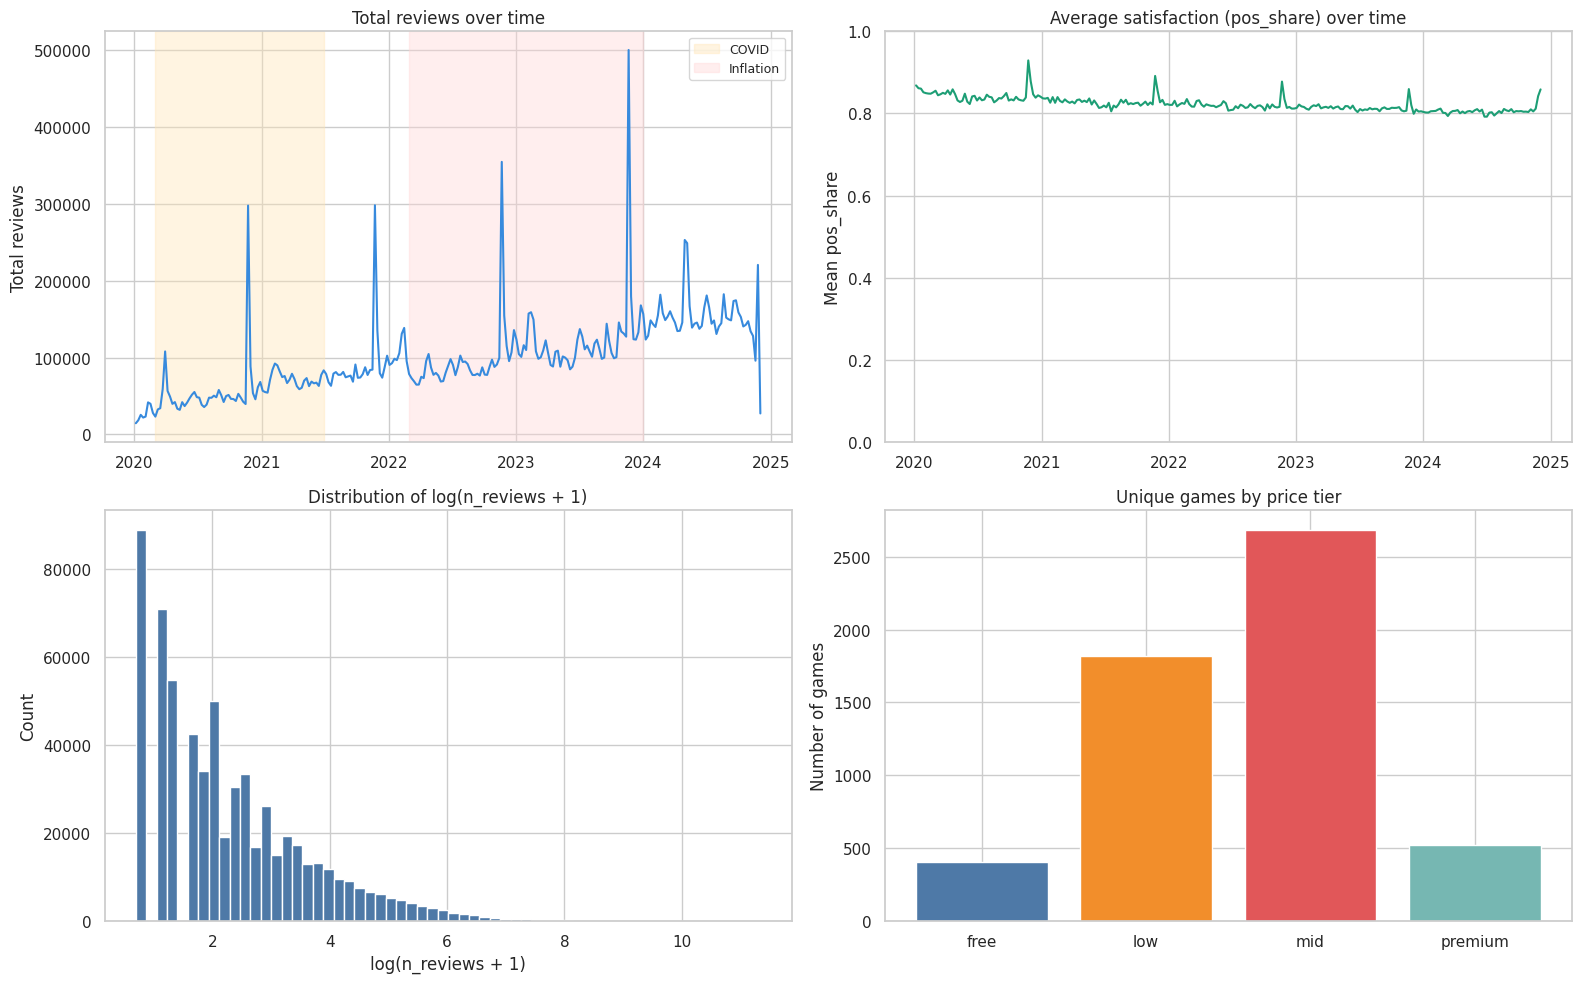

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1: Reviews over time by period
ax = axes[0, 0]
ts = panel_merged.groupby('year_week')['n_reviews'].sum().reset_index()
ax.plot(ts['year_week'], ts['n_reviews'], linewidth=1.5, color='#378ADD')
for start, end, color, label in [
    ('2020-03-01', '2021-06-30', '#FFE5B4', 'COVID'),
    ('2022-03-01', '2023-12-31', '#FFD6D6', 'Inflation'),
]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.4, color=color, label=label)
ax.set_title('Total reviews over time', fontsize=12)
ax.set_ylabel('Total reviews')
ax.legend(fontsize=9)

# 2: Average satisfaction over time
ax = axes[0, 1]
sat = panel_merged.groupby('year_week')['pos_share'].mean().reset_index()
ax.plot(sat['year_week'], sat['pos_share'], linewidth=1.5, color='#1D9E75')
ax.set_title('Average satisfaction (pos_share) over time', fontsize=12)
ax.set_ylabel('Mean pos_share')
ax.set_ylim(0, 1)

# 3: Distribution of log(n_reviews)
ax = axes[1, 0]
ax.hist(np.log1p(panel_merged['n_reviews']), bins=60, color='#4e79a7', edgecolor='white')
ax.set_title('Distribution of log(n_reviews + 1)', fontsize=12)
ax.set_xlabel('log(n_reviews + 1)')
ax.set_ylabel('Count')

# 4: Games per price tier
ax = axes[1, 1]
if 'price_tier' in panel_merged.columns:
    tc = panel_merged.groupby('price_tier')['appID'].nunique()
    ax.bar(tc.index, tc.values,
           color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'],
           edgecolor='white')
    ax.set_title('Unique games by price tier', fontsize=12)
    ax.set_ylabel('Number of games')

plt.tight_layout()
plt.show()


1. Top left — Total reviews over time <br>
This is the most informative plot. A few things stand out:
The good: You can clearly see the review ecosystem growing over time, which validates that your 2020–2024 window captures a meaningful expansion period. The COVID and inflation shading is correctly placed.
The spike at early 2024 is very large — around 500,000 reviews in a single week. This almost certainly corresponds to a specific event, likely a major game release or a review-bomb campaign.

2. Top right — Average pos_share over time
This is remarkably stable — hovering around 0.80–0.85 throughout the entire period with very little trend. A few observations:
The good: Stability means DV isn't dominated by a long-run trend, which makes the panel regression cleaner. Time fixed effects won't need to absorb a large trend component.
The spike around early 2022 — satisfaction briefly jumps to near 0.95. This is worth investigating. A possible explanation is that during that period, only games receiving very positive reviews had enough volume to appear in the weekly panel, creating a selection artifact. Or it corresponds to a specific set of highly-rated games releasing simultaneously.
The slight dip around 2023 aligns with the inflation period, which is consistent with hypothesis that constrained consumers were more selective and critical. That's a small but encouraging preliminary signal.

3. Bottom left — Distribution of log(n_reviews + 1)
The heavy right skew is completely expected and healthy. The vast majority of game-weeks have very few reviews — this is the nature of the Steam ecosystem where a small number of large games dominate volume.
The log transformation is the right way to display this. It confirms that using n_reviews directly in any regression would be problematic — you'll want to use log(n_reviews + 1) as a control variable in Stage 3, not the raw count.
The large bar at log = 0–1 (roughly 1–3 reviews per week) means a lot of your observations are from small games with sparse activity. This is actually why the minimum lifetime reviews filter matters — without it, this bar would be even more extreme and those near-zero games would be generating false surges.

4. Bottom right — Games by price tier
The distribution makes intuitive sense for Steam — low and mid dominate, free and premium are smaller. No red flags here.


---
# 8. Save the Clean Panel

This file is the **single input** for Stage 2 (surge detection).
Never modify it after saving — if you need to change any cleaning decision,
re-run this entire notebook from scratch.


In [62]:
keep_cols = [
    'appID', 'name',
    'iso_year', 'iso_week', 'year_week',
    'n_reviews', 'pos_share', 'avg_helpful',
    'release_date', 'price', 'price_tier',
    'game_age_months', 'is_mature',
    'lifetime_pos_share', 'total_lifetime_reviews',
    'period', 'covid_period', 'inflation_period', 'post_covid_period'
]
for col in ['genres', 'categories']:
    if col in panel_merged.columns:
        keep_cols.append(col)

final_panel = (
    panel_merged[[c for c in keep_cols if c in panel_merged.columns]]
    .sort_values(['appID', 'year_week'])
    .reset_index(drop=True)
)

final_panel.to_csv(OUTPUT_PATH, index=False)
print(f'Saved   : {OUTPUT_PATH}')
print(f'Shape   : {final_panel.shape}')
print(f'Columns : {list(final_panel.columns)}')

Saved   : drive/My Drive/Notebooks/PersonalResearch/panel_stage1_lr200.csv
Shape   : (627631, 21)
Columns : ['appID', 'name', 'iso_year', 'iso_week', 'year_week', 'n_reviews', 'pos_share', 'avg_helpful', 'release_date', 'price', 'price_tier', 'game_age_months', 'is_mature', 'lifetime_pos_share', 'total_lifetime_reviews', 'period', 'covid_period', 'inflation_period', 'post_covid_period', 'genres', 'categories']


---
# 9. Checklist Before Moving to Stage 2

### Must-confirm before opening Stage 2
- [ ] Missing `pos_share` < 5% (Section 7 check passed)
- [ ] All four periods have non-zero coverage
- [ ] n_reviews <= 0 rows = 0 (or small and explainable)
- [ ] pos_share outside [0,1] = 0
- [ ] Review volume plot shows expected seasonal patterns (holiday spikes)
- [ ] Output file read-back passed

### Analytical choices to justify in your thesis methods section
- Why the 2020–2024 window (not 2018–2024)
- Why `estimated_owners != '0 - 0'` as the commercial filter
- Why MIN_LIFETIME_REVIEWS = 50 (test 100 and 200 as robustness)
- Why MIN_ACTIVE_PERIODS = 6 (tied to Stage 2 window length)
- Weekly vs monthly granularity
- The three macroeconomic period boundaries and how they're justified

### Next step
Open the **surge_detection notebook (Stage 2)** and point `PATH` at `panel_stage1_clean.csv`.
